In [1]:
import torch
import tiktoken

<div align="center">
  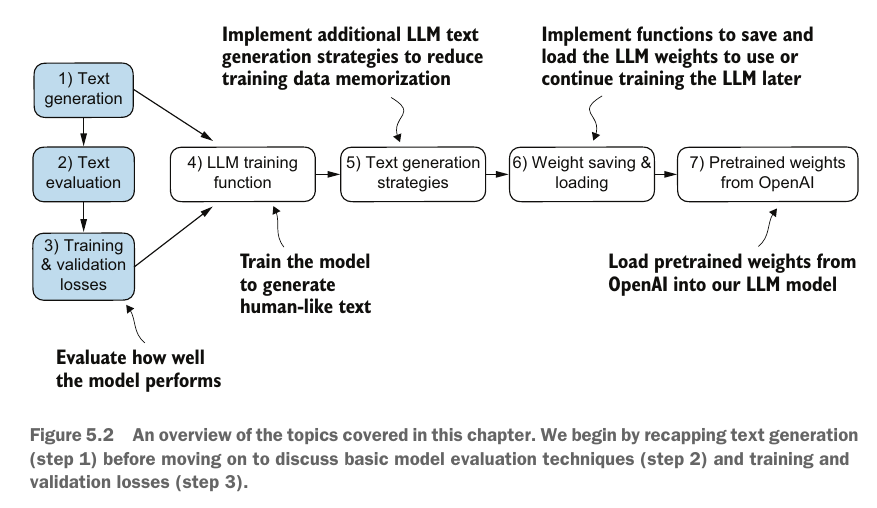
</div>

In [2]:
%run Ch04_GPT.ipynb
%run GPT_CONFIG_124M_Modified.ipynb

In [3]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # adds the batch dimension
    return encoded_tensor

In [4]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze() # removes the batch dimension
    return tokenizer.decode(flat.tolist())

In [5]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.eval(); # disables dropout since we are not training the model

In [6]:
text = "Every effort moves you"

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    token_ids=text_to_token_ids(text, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

In [7]:
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren
